# 📌 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

# 📌 2. Load Data
data = pd.read_csv('car_price_prediction_dataset.csv')

# 📌 3. Basic Exploration
print(data.info())
print(data.describe())
print(data.isnull().sum())

# 📌 4. Fill Missing Values
for col in data.select_dtypes(include=np.number).columns:
    data[col].fillna(data[col].median(), inplace=True)

for col in data.select_dtypes(exclude=np.number).columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# 📌 5. Drop Duplicates
data.drop_duplicates(inplace=True)

# 📌 6. Encode Categorical Columns
label_encoders = {}
categorical_cols = ['Brand', 'Fuel_Type', 'Transmission']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# 📌 7. Outlier Removal Using IQR
numeric_cols = data.select_dtypes(include=np.number).columns
mask = pd.Series(True, index=data.index)

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= data[col].between(lower_bound, upper_bound)

data_cleaned = data[mask]

# 📌 8. Split Data
X = data_cleaned.drop('Price_Lakhs', axis=1)
y = data_cleaned['Price_Lakhs']

# 📌 9. Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 📌 10. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 📌 11. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 📌 12. Predict
y_pred = model.predict(X_test)

# 📌 13. Evaluation
df_preds = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(df_preds.head(10))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n📊 Mean Absolute Error: {mae:.2f}")
print(f"📉 Root Mean Squared Error: {rmse:.2f}")

# 📌 14. Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# 📌 15. Predict User Input
def predict_car_price():
    print("\nEnter car details for price prediction:")

    for i, brand in enumerate(label_encoders['Brand'].classes_):
        print(f"{i}: {brand}")
    brand_input = int(input("Enter Brand number: "))

    year = int(input("Model Year (e.g. 2015): "))

    for i, fuel in enumerate(label_encoders['Fuel_Type'].classes_):
        print(f"{i}: {fuel}")
    fuel_input = int(input("Enter Fuel Type number: "))

    for i, trans in enumerate(label_encoders['Transmission'].classes_):
        print(f"{i}: {trans}")
    trans_input = int(input("Enter Transmission number: "))

    kms = float(input("Kilometers Driven: "))
    engine = float(input("Engine CC: "))
    seats = float(input("Number of Seats: "))

    new_car = pd.DataFrame([[brand_input, year, fuel_input, trans_input, kms, engine, seats]],
                           columns=X.columns)
    new_car_scaled = scaler.transform(new_car)

    predicted_price = model.predict(new_car_scaled)[0]
    print(f"\n🚗 Predicted Price: Rs {predicted_price:.2f} Lakhs")

# Uncomment to run the prediction function
predict_car_price()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        200 non-null    int64  
 1   Brand         200 non-null    object 
 2   Model_Year    200 non-null    int64  
 3   Fuel_Type     200 non-null    object 
 4   Transmission  200 non-null    object 
 5   KMs_Driven    180 non-null    float64
 6   Engine_CC     180 non-null    float64
 7   Seats         180 non-null    float64
 8   Price_Lakhs   200 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 14.2+ KB
None
           Car_ID   Model_Year     KMs_Driven    Engine_CC       Seats  \
count  200.000000   200.000000     180.000000   180.000000  180.000000   
mean   100.500000  2010.905000  104292.411111  2032.311111    5.522222   
std     57.879185     7.195474   53970.532584   667.355720    1.085483   
min      1.000000  2000.000000   10404.000000   803.000000 

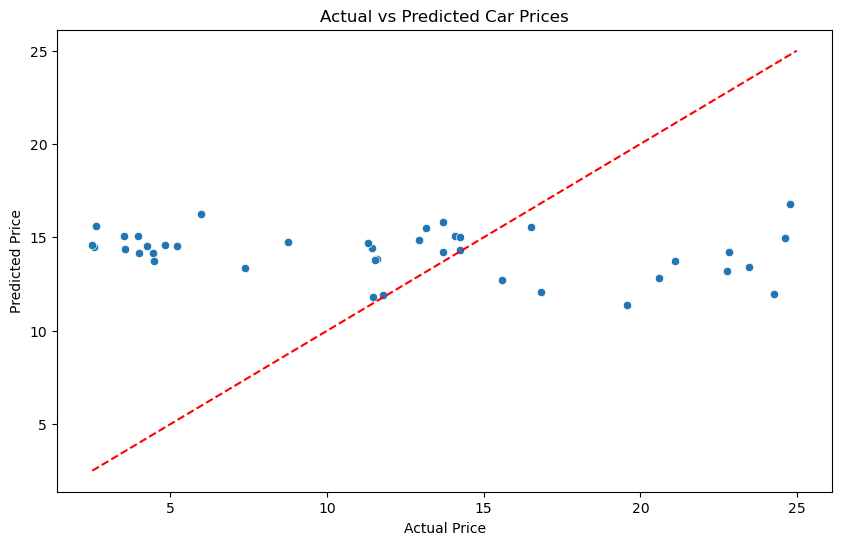


Enter car details for price prediction:
0: BMW
1: Ford
2: Honda
3: Hyundai
4: Toyota
Enter Brand number: 2
Model Year (e.g. 2015): 2
0: Diesel
1: Electric
2: Hybrid
3: Petrol
Enter Fuel Type number: 2
0: Automatic
1: Manual
Enter Transmission number: 


ValueError: invalid literal for int() with base 10: ''

In [6]:
# 📌 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

# 📌 2. Load Data
data = pd.read_csv('car_price_prediction_dataset.csv')

# 📌 3. Basic Exploration
print(data.info())
print(data.describe())
print(data.isnull().sum())

# 📌 4. Fill Missing Values
for col in data.select_dtypes(include=np.number).columns:
    data[col].fillna(data[col].median(), inplace=True)

for col in data.select_dtypes(exclude=np.number).columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# 📌 5. Drop Duplicates
data.drop_duplicates(inplace=True)

# 📌 6. Encode Categorical Columns
label_encoders = {}
categorical_cols = ['Brand', 'Fuel_Type', 'Transmission']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# 📌 7. Outlier Removal Using IQR
numeric_cols = data.select_dtypes(include=np.number).columns
mask = pd.Series(True, index=data.index)

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= data[col].between(lower_bound, upper_bound)

data_cleaned = data[mask]

# 📌 8. Split Data
X = data_cleaned.drop('Price_Lakhs', axis=1)
y = data_cleaned['Price_Lakhs']

# 📌 9. Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 📌 10. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 📌 11. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 📌 12. Predict
y_pred = model.predict(X_test)

# 📌 13. Evaluation
df_preds = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(df_preds.head(10))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n📊 Mean Absolute Error: {mae:.2f}")
print(f"📉 Root Mean Squared Error: {rmse:.2f}")

# 📌 14. Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# 📌 15. Predict User Input
def predict_car_price():
    print("\nEnter car details for price prediction:")

    for i, brand in enumerate(label_encoders['Brand'].classes_):
        print(f"{i}: {brand}")
    brand_input = int(input("Enter Brand number: "))

    year = int(input("Model Year (e.g. 2015): "))

    for i, fuel in enumerate(label_encoders['Fuel_Type'].classes_):
        print(f"{i}: {fuel}")
    fuel_input = int(input("Enter Fuel Type number: "))

    for i, trans in enumerate(label_encoders['Transmission'].classes_):
        print(f"{i}: {trans}")
    trans_input = int(input("Enter Transmission number: "))

    kms = float(input("Kilometers Driven: "))
    engine = float(input("Engine CC: "))
    seats = float(input("Number of Seats: "))

    new_car = pd.DataFrame([[brand_input, year, fuel_input, trans_input, kms, engine, seats]],
                           columns=X.columns)
    new_car_scaled = scaler.transform(new_car)

    predicted_price = model.predict(new_car_scaled)[0]
    print(f"\n🚗 Predicted Price: Rs {predicted_price:.2f} Lakhs")

# Uncomment to run the prediction function
predict_car_price()


In [7]:
 # 5. Linear Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

plt.figure(figsize=(12, 8))
plt.scatter(x=data_scaled['KMs_Driven'], y=data_scaled['Price_Lakhs'])
plt.title('Scatterplot of Kilometers Driven vs Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (in Lakhs)')
plt.show()

X = data_cleaned.drop(['Car_ID', 'Price_Lakhs'], axis=1).values
y = data_cleaned['Price_Lakhs'].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


regressor = LinearRegression()
regressor.fit(X_train, y_train)


print("\nModel intercept:", regressor.intercept_)
print("Model coefficients:", regressor.coef_)


y_pred = regressor.predict(X_test)


df_preds = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': y_pred.squeeze()})
print("\nActual vs Predicted prices:")
print(df_preds.head(10))

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Performance Metrics:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

NameError: name 'data_scaled' is not defined

<Figure size 1200x800 with 0 Axes>

In [9]:
## Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data=pd.read_csv('car_price_prediction_dataset.csv')

## 1. Reading data by Pandas Simple Operations

data.sample()

data.head()

data.tail()

## Checking Data Types  and Information

data.dtypes

data.describe()

data.info()

## 2. Data Cleaning

## Checking Null Values

data.isnull().sum()

__Separate numeric and non-numeric columns__

numeric_cols=data.select_dtypes(include=[np.number])
non_numeric_cols=data.select_dtypes(exclude=[np.number])

__Fill missing values in numeric columns with the mean and non_numeric by mode__

numeric_cols.fillna(numeric_cols.mean(),inplace=True)
non_numeric_cols.fillna(non_numeric_cols.mode(),inplace=True)


__Combine back with non-numeric columns__

data=pd.concat([numeric_cols,non_numeric_cols],axis=1)

data.isnull().sum()

## Droping Missing Values and Duplicate values


__In this case there is no missing value column so we do not do this process__

# data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

## Checking shape of data

data.shape



numeric_cols = data.select_dtypes(include=['float64']).columns
mask = pd.Series(True, index=data.index)

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = mask & data[col].between(lower_bound, upper_bound)

data_cleaned = data[mask]


__Visualizing the data before outlier removal__

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
data.boxplot()
plt.title("Before Outliers removal")
plt.tight_layout()
plt.show()

## Removing Outliers

__Visualizing the data after outlier removal__

plt.figure(figsize=(30,6))
plt.subplot(1,2,1)
data_cleaned.boxplot()
plt.title("After Outliers removal")
plt.tight_layout()
plt.show()

# 4. Data Transformation


from sklearn.preprocessing import MinMaxScaler
numeric_cols = data.select_dtypes(include=['float64']).columns
numeric_data = data[numeric_cols]
scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)
scaled_numeric_data = pd.DataFrame(scaled_numeric_data, columns=numeric_cols)
non_numeric_data = data.drop(columns=numeric_cols).reset_index(drop=True)
scaled_data = pd.concat([scaled_numeric_data, non_numeric_data], axis=1)
print(scaled_data.shape)
print()
print('*' * 60)
scaled_data.head()



from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numeric_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
data_scaled = pd.DataFrame(scaler.fit_transform(data_cleaned[numeric_cols]), columns=numeric_cols)
plt.figure(figsize=(16, 6))
data_scaled.boxplot()
plt.title("📊 Boxplot After Outlier Removal and Standardization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()







# 5. Linear Regression


SyntaxError: invalid syntax (2296596424.py, line 31)

Sample data:
     car_ID  symboling                   CarName fueltype aspiration  \
139     140          2                 subaru dl      gas        std   
132     133          3                  saab 99e      gas        std   
68       69         -1  buick century luxus (sw)   diesel      turbo   
185     186          2         volkswagen type 3      gas        std   
196     197         -2               volvo 244dl      gas        std   

    doornumber    carbody drivewheel enginelocation  wheelbase  ...  \
139        two  hatchback        fwd          front       93.7  ...   
132        two  hatchback        fwd          front       99.1  ...   
68        four      wagon        rwd          front      110.0  ...   
185       four      sedan        fwd          front       97.3  ...   
196       four      sedan        rwd          front      104.3  ...   

     enginesize  fuelsystem  boreratio  stroke compressionratio horsepower  \
139         108        2bbl       3.62    2.64   

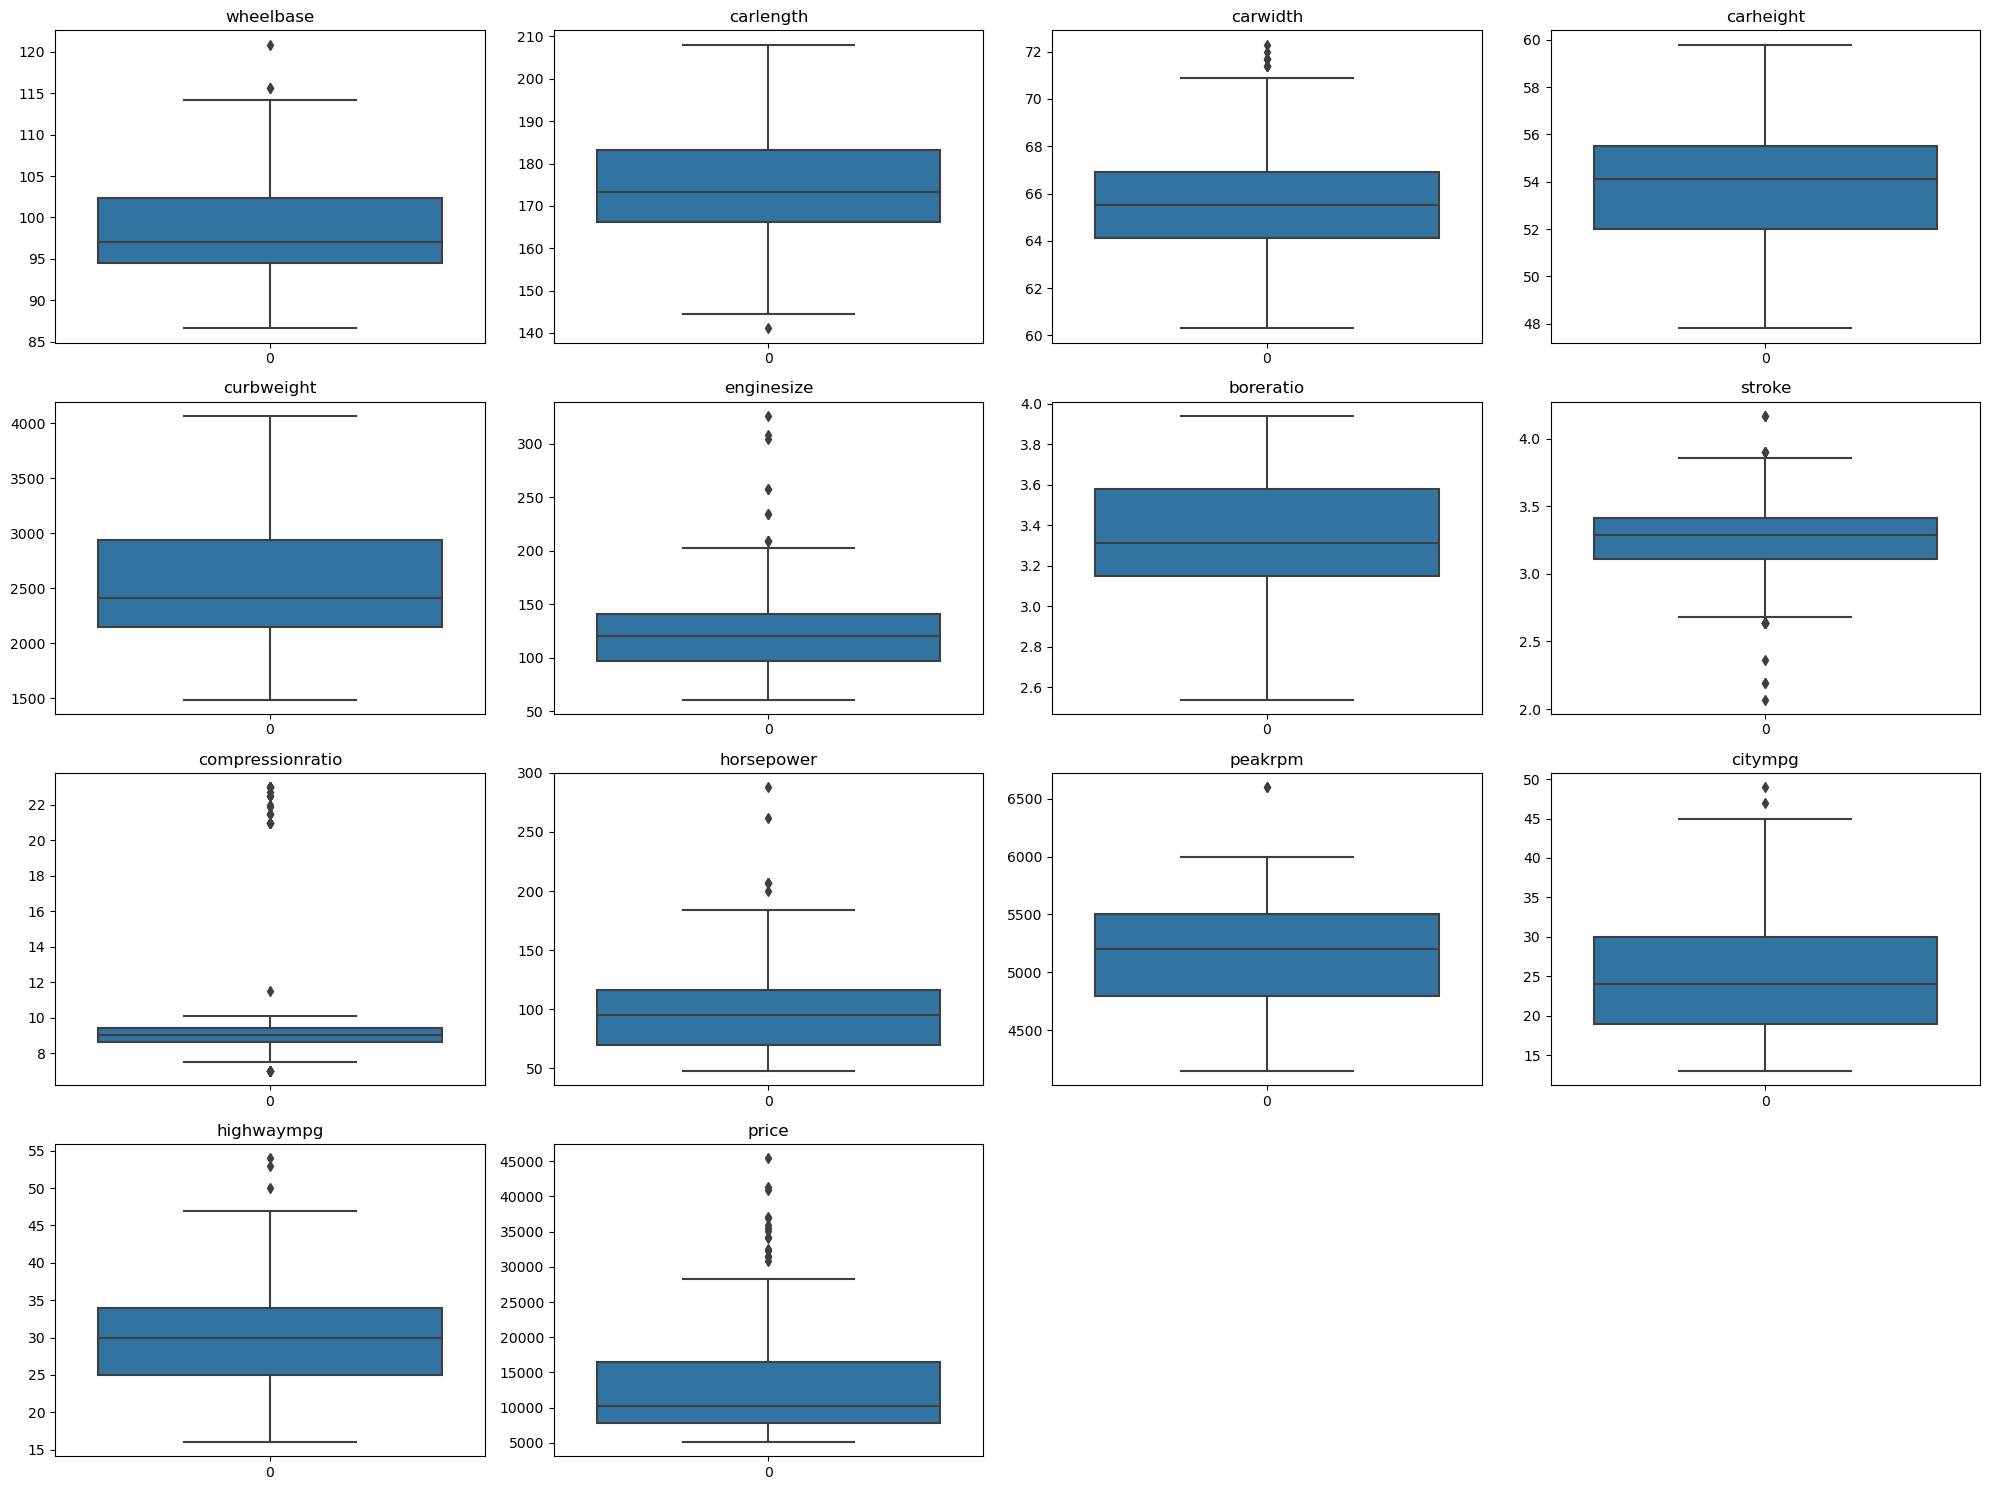

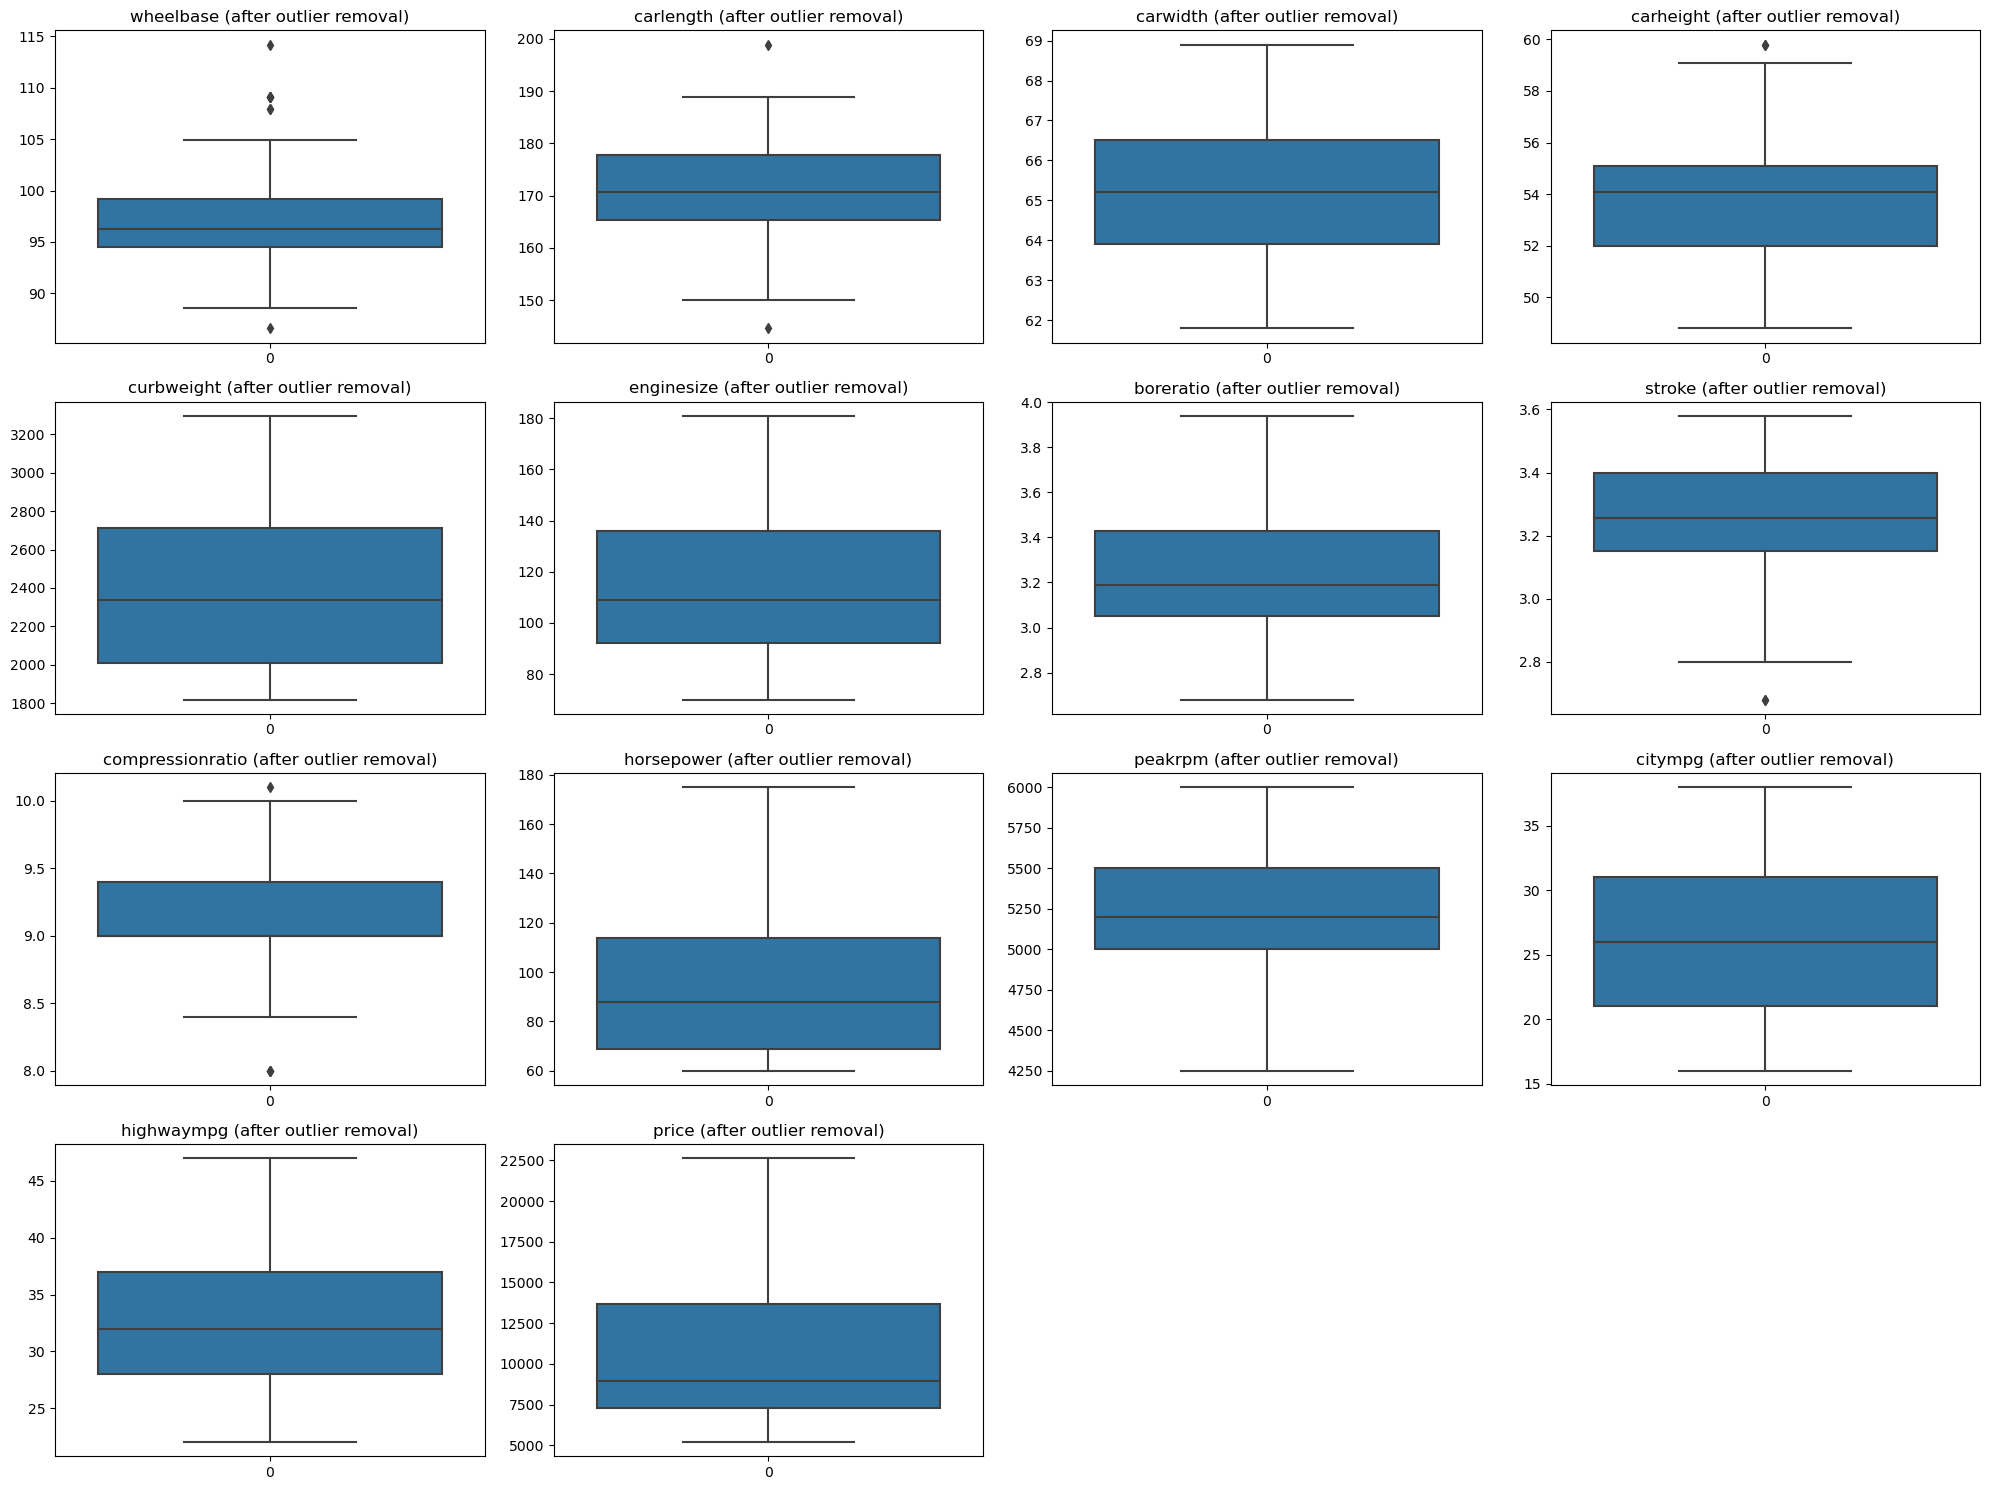


Model Evaluation:
MAE: 1981.01
MSE: 5798181.80


ValueError: Format specifier missing precision

In [1]:
# Preprocessing of Dataset

## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
data = pd.read_csv('CarPrice_Assignment.csv')

## 1. Reading data by Pandas Simple Operations
print("Sample data:")
print(data.sample(5))
print("\nFirst 5 rows:")
print(data.head())
print("\nLast 5 rows:")
print(data.tail())

## Checking Data Types and Information
print("\nData types:")
print(data.dtypes)
print("\nDescriptive statistics:")
print(data.describe())
print("\nDataset info:")
print(data.info())

## 2. Data Cleaning
## Checking Null Values
print("\nMissing values per column:")
print(data.isnull().sum())

# No missing values found, so no need for imputation

# Check for duplicates
print("\nNumber of duplicates:", data.duplicated().sum())
data.drop_duplicates(inplace=True)

## 3. Checking Outliers
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop(['car_ID', 'symboling'])  # Exclude ID and categorical numeric columns

# Visualize outliers before removal
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Remove outliers using IQR method
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

# Visualize after outlier removal
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data[col])
    plt.title(f"{col} (after outlier removal)")
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Transformation
# Extract brand from CarName
data['brand'] = data['CarName'].str.split().str[0].str.lower()

# Correct some brand names
brand_mapping = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}
data['brand'] = data['brand'].replace(brand_mapping)

# Label Encoding for categorical variables
categorical_cols = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 
                   'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Standardization of numeric features
numeric_cols_for_model = ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
                         'enginesize', 'boreratio', 'stroke', 'compressionratio',
                         'horsepower', 'peakrpm', 'citympg', 'highwaympg']

scaler = StandardScaler()
data[numeric_cols_for_model] = scaler.fit_transform(data[numeric_cols_for_model])

## 5. Linear Regression Model
# Prepare features and target
X = data.drop(['car_ID', 'CarName', 'price'], axis=1)
y = data['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)

print("\nModel Evaluation:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):..2f}")
print(f"R-squared: {model.score(X_test, y_test):.2f}")

# Visualize actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()

# Show feature importance
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print("\nFeature coefficients:")
print(coefficients)

## Prediction Function
def predict_car_price():
    print("\nEnter car details for price prediction:")
    
    # Get brand input
    print("\nAvailable Brands:")
    brands = label_encoders['brand'].classes_
    for i, brand in enumerate(brands):
        print(f"{i}: {brand}")
    brand_input = int(input("Enter Brand number: "))
    
    # Get other features
    fueltype = int(input("Fuel type (0: gas, 1: diesel): "))
    aspiration = int(input("Aspiration (0: std, 1: turbo): "))
    doornumber = int(input("Door number (0: two, 1: four): "))
    carbody = int(input("Car body type (0-4): "))
    drivewheel = int(input("Drive wheel (0-2): "))
    enginelocation = int(input("Engine location (0: front, 1: rear): "))
    wheelbase = float(input("Wheelbase (inches): "))
    carlength = float(input("Car length (inches): "))
    carwidth = float(input("Car width (inches): "))
    carheight = float(input("Car height (inches): "))
    curbweight = float(input("Curb weight (lbs): "))
    enginetype = int(input("Engine type (0-6): "))
    cylindernumber = int(input("Cylinder number (0-6): "))
    enginesize = float(input("Engine size (cc): "))
    fuelsystem = int(input("Fuel system (0-7): "))
    boreratio = float(input("Bore ratio: "))
    stroke = float(input("Stroke: "))
    compressionratio = float(input("Compression ratio: "))
    horsepower = float(input("Horsepower: "))
    peakrpm = float(input("Peak RPM: "))
    citympg = float(input("City MPG: "))
    highwaympg = float(input("Highway MPG: "))
    
    # Scale numeric features
    numeric_features = [wheelbase, carlength, carwidth, carheight, curbweight,
                       enginesize, boreratio, stroke, compressionratio,
                       horsepower, peakrpm, citympg, highwaympg]
    
    # Scale the input features
    scaled_features = scaler.transform([numeric_features])
    
    # Create feature array
    features = [brand_input, fueltype, aspiration, doornumber, carbody, drivewheel,
                enginelocation, enginetype, cylindernumber, fuelsystem]
    features.extend(scaled_features[0])
    
    # Make prediction
    predicted_price = model.predict([features])[0]
    print(f"\nPredicted Price: ${predicted_price:.2f}")

# Uncomment to run the prediction function
predict_car_price()

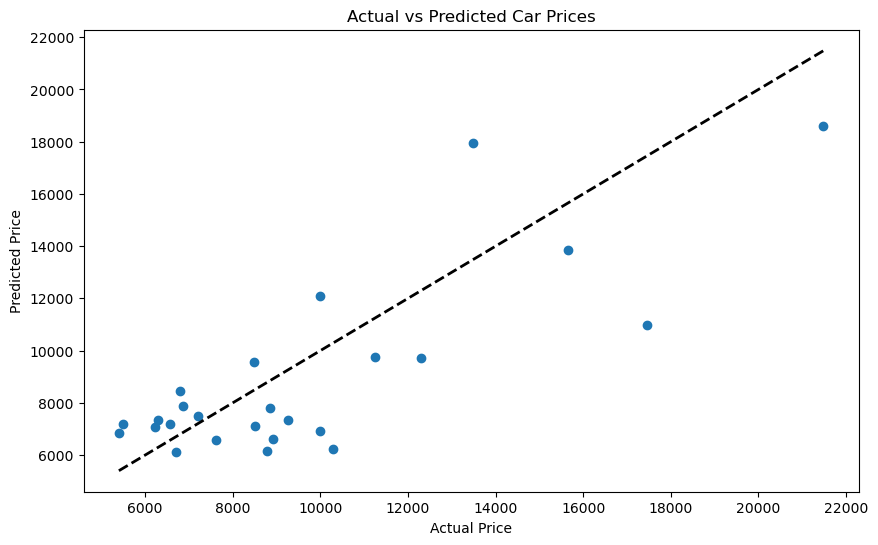

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('CarPrice_Assignment.csv')

# Display the first few rows
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Drop 'CarName' as it's not useful for prediction
df.drop('CarName', axis=1, inplace=True)

# Convert categorical variables to dummy variables
categorical_cols = ['fueltype', 'aspiration', 'doornumber', 'carbody',
                    'drivewheel', 'enginelocation', 'enginetype',
                    'cylindernumber', 'fuelsystem']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features and target variable
X = df.drop(['car_ID', 'price'], axis=1)
y = df['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

# Plot actual vs predicted prices
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Car Prices')
plt.show()


   Unnamed: 0       Make      Model  Year  Mileage  Condition     Price
0           0       Ford  Silverado  2022    18107  Excellent  19094.75
1           1     Toyota  Silverado  2014    13578  Excellent  27321.10
2           2  Chevrolet      Civic  2016    46054       Good  23697.30
3           3       Ford      Civic  2022    34981  Excellent  18251.05
4           4  Chevrolet      Civic  2019    63565  Excellent  19821.85
Unnamed: 0    0
Make          0
Model         0
Year          0
Mileage       0
Condition     0
Price         0
dtype: int64


KeyError: 'price'

Optimized Linear Regression Results:
Mean Squared Error: 53.94
R² Score: -0.20


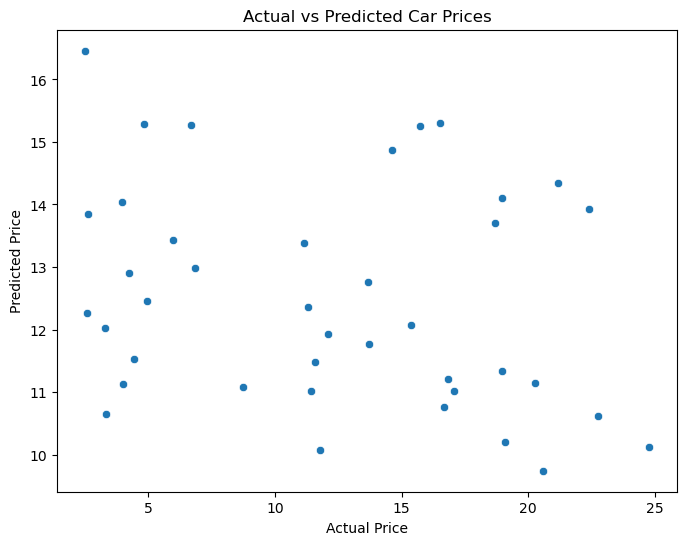

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("car_price_prediction_dataset.csv")

# Handle missing values
df['KMs_Driven'].fillna(df['KMs_Driven'].median(), inplace=True)
df['Engine_CC'].fillna(df['Engine_CC'].median(), inplace=True)
df['Seats'].fillna(df['Seats'].median(), inplace=True)

# Remove extreme price outliers
df = df[df['Price_Lakhs'] <= df['Price_Lakhs'].quantile(0.99)]

# Log-transform skewed features and the target
df['KMs_Driven'] = np.log1p(df['KMs_Driven'])
df['Engine_CC'] = np.log1p(df['Engine_CC'])
df['Price_Lakhs'] = np.log1p(df['Price_Lakhs'])

# Drop ID if present
if 'Car_ID' in df.columns:
    df.drop(columns=['Car_ID'], inplace=True)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Split into features and target
X = df_encoded.drop('Price_Lakhs', axis=1)
y = df_encoded['Price_Lakhs']

# Feature selection (optional)
X_selected = SelectKBest(score_func=f_regression, k='all').fit_transform(X, y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict and inverse transform
y_pred_log = model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# Evaluate
mse = mean_squared_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print(f"Optimized Linear Regression Results:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_actual, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("CarPricesPrediction.csv")
df.columns = df.columns.str.strip()

# Drop unnecessary columns, such as the index column if present
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Encode categorical features
label_encoders = {}
for col in ['Make', 'Model', 'Condition']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

# Evaluation (optional)
y_pred = regression_model.predict(X_test)
print("\nEvaluation Metrics:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

# Prediction function
def predict_price(make, model, year, mileage, condition):
    try:
        # Encode inputs
        make_encoded = label_encoders['Make'].transform([make])[0]
        model_encoded = label_encoders['Model'].transform([model])[0]
        condition_encoded = label_encoders['Condition'].transform([condition])[0]

        # Create input array with the same column order as the training data
        input_data = pd.DataFrame([[make_encoded, model_encoded, year, mileage, condition_encoded]],
                                  columns=['Make', 'Model', 'Year', 'Mileage', 'Condition'])

        # Predict
        predicted_price = regression_model.predict(input_data)[0]
        return round(predicted_price, 2)

    except ValueError as e:
        return f"Input error: {e}"

# Example usage:
print("\nExample Prediction:")
price = predict_price('Ford', 'Civic', 2020, 50000, 'Good')
print(f"Predicted Price: ${price}")



Evaluation Metrics:
MAE: 0.06
RMSE: 0.07
R²: 1.00

Example Prediction:
Predicted Price: $19500.05
